<a href="https://colab.research.google.com/github/arya2005-tech/CSL701-CS44-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Arya Abhiram Prabhudesai

Batch :CS-3


Roll Number : CS44



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [6]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Kaggle Dataset URL
url = "https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset"

# If brca.csv is uploaded in Colab
df = pd.read_csv("brca.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows of the dataset:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.2

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [7]:
# Task 2: Explore the Dataset

# Display column names
print("Column Names:")
print(df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Dataset dimensions
print("\nDataset Dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Check class distribution
print("\nDiagnosis Class Distribution:")
print(df["y"].value_counts())

# Display Malignant and Benign counts
print("\nMalignant (M):", (df["y"] == "M").sum())
print("Benign (B):", (df["y"] == "B").sum())

Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se            

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [8]:
# Task 3: Preprocess and Scale Features

from sklearn.preprocessing import StandardScaler

# Select numerical columns
X = df.select_dtypes(include=["int64", "float64"])

# Remove identifier column
if "Unnamed: 0" in X.columns:
    X = X.drop(columns=["Unnamed: 0"])

if "id" in X.columns:
    X = X.drop(columns=["id"])

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display information
print("Original Feature Shape:", X.shape)
print("Scaled Feature Shape:", X_scaled.shape)

print("\nFirst 5 rows after scaling:")
print(X_scaled.head())

Original Feature Shape: (569, 30)
Scaled Feature Shape: (569, 30)

First 5 rows after scaling:
   x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0      -0.166799       -1.147162         -0.185728    -0.251957   
1      -0.297446       -0.833008         -0.261106    -0.383638   
2      -1.313080       -1.593959         -1.302806    -1.083572   
3      -0.311646       -0.202373         -0.385500    -0.372831   
4      -1.684571       -0.570050         -1.658278    -1.288347   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0           0.101747           -0.436850         -0.278210   
1           0.792763            0.429422         -0.541362   
2           0.429819           -0.747086         -0.743748   
3          -0.464730           -1.263703         -0.793214   
4          -0.737294           -0.851130         -0.915500   

   x.concave_pts_mean  x.symmetry_mean  x.fractal_dim_mean  ...  \
0           -0.028609         0.267911           -0.728310  ..

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [9]:
# Task 4: Construct Pairwise Distance Matrix & Graph

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial.distance import pdist, squareform

# Compute pairwise Euclidean distances
distance_vector = pdist(X_scaled, metric="euclidean")

# Convert distances into square matrix
distance_matrix = squareform(distance_vector)

print("Distance Matrix Shape:")
print(distance_matrix.shape)

print("\nFirst 5 x 5 Distance Matrix:")
print(distance_matrix[:5, :5])

# Create weighted complete graph using first 20 samples
n = 20

G = nx.Graph()

# Add nodes
for i in range(n):
    G.add_node(i)

# Add weighted edges
for i in range(n):
    for j in range(i + 1, n):
        G.add_edge(i, j, weight=distance_matrix[i, j])

print("\nNumber of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape:
(569, 569)

First 5 x 5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]

Number of Nodes: 20
Number of Edges: 190


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [10]:
# Task 5: Compute Minimum Spanning Tree (MST)

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.sparse.csgraph import minimum_spanning_tree

# Compute MST from distance matrix
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert MST to NumPy matrix
mst_matrix = mst_sparse.toarray()

print("MST Matrix:")
print(mst_matrix)

# Create NetworkX graph
MST = nx.from_numpy_array(mst_matrix)

# Remove zero-weight edges
MST.remove_edges_from(
    [
        (u, v)
        for u, v, d in MST.edges(data=True)
        if d["weight"] == 0
    ]
)

# Display MST connections and weights
print("\nMST Connections and Weights:")

for u, v, data in MST.edges(data=True):
    print(
        f"Node {u} -- Node {v} : "
        f"Weight = {data['weight']:.3f}"
    )

print("\nNumber of MST Nodes:", MST.number_of_nodes())
print("Number of MST Edges:", MST.number_of_edges())

MST Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

MST Connections and Weights:
Node 0 -- Node 81 : Weight = 1.689
Node 0 -- Node 108 : Weight = 2.171
Node 1 -- Node 105 : Weight = 1.661
Node 2 -- Node 70 : Weight = 2.219
Node 3 -- Node 170 : Weight = 2.346
Node 3 -- Node 222 : Weight = 2.542
Node 4 -- Node 84 : Weight = 2.166
Node 4 -- Node 279 : Weight = 1.860
Node 5 -- Node 125 : Weight = 1.766
Node 5 -- Node 172 : Weight = 2.017
Node 6 -- Node 336 : Weight = 1.420
Node 6 -- Node 393 : Weight = 1.693
Node 7 -- Node 140 : Weight = 1.773
Node 8 -- Node 66 : Weight = 1.511
Node 9 -- Node 95 : Weight = 1.673
Node 9 -- Node 126 : Weight = 1.576
Node 9 -- Node 192 : Weight = 1.626
Node 10 -- Node 126 : Weight = 1.778
Node 11 -- Node 140 : Weight = 1.325
Node 11 -- Node 192 : Weight = 1.840
Node 12 -- Node 322 : Weight = 1.996
Node 13 -- Node 191 : Weight = 3.198
Node 13 --

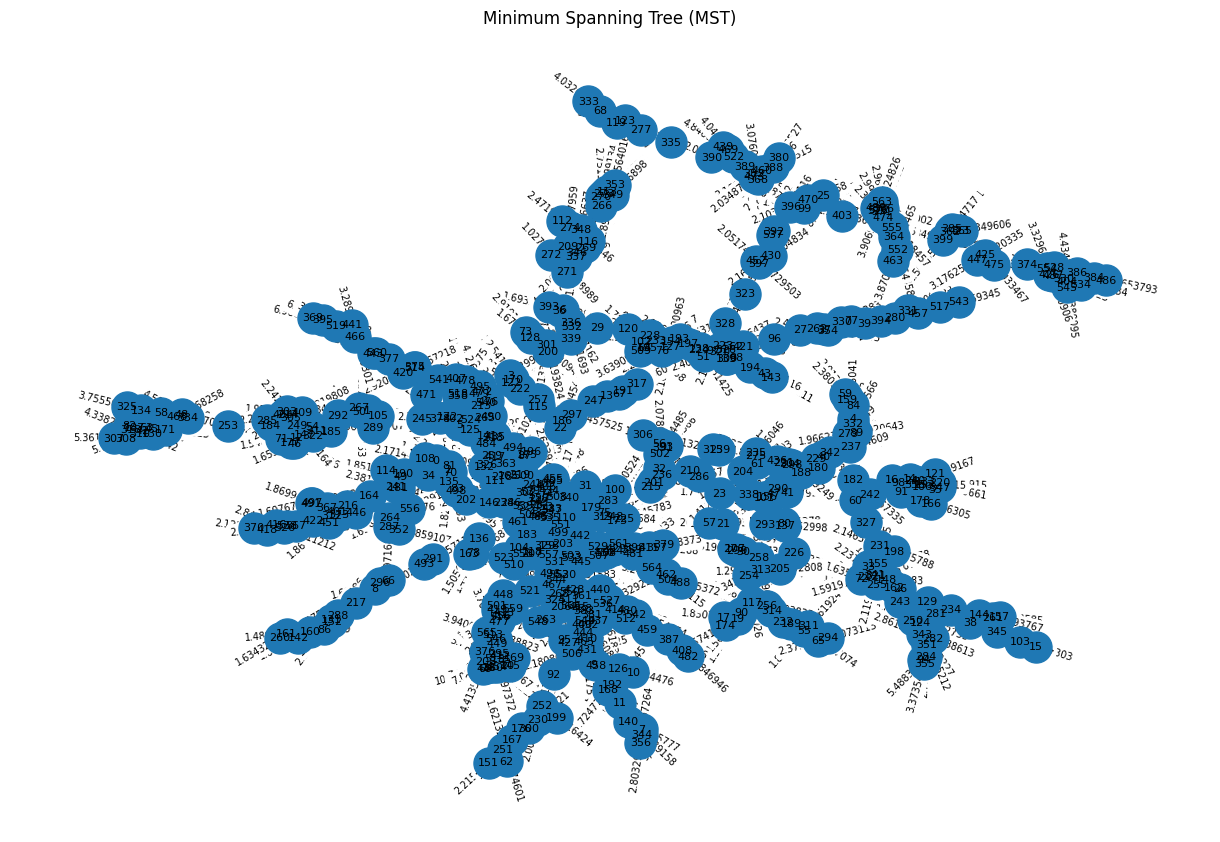

In [11]:
# MST Graph Visualization

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(MST, seed=42)

nx.draw(
    MST,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

# Display edge weights
edge_labels = nx.get_edge_attributes(MST, "weight")

nx.draw_networkx_edge_labels(
    MST,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Minimum Spanning Tree (MST)")
plt.show()

# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [12]:
# Task 6: Graph-Based Clustering (K = 2)

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Make a copy of MST
cluster_graph = MST.copy()

# Get all MST edges with weights
edges = list(cluster_graph.edges(data=True))

# Sort edges by weight in descending order
edges_sorted = sorted(
    edges,
    key=lambda x: x[2]["weight"],
    reverse=True
)

# Get largest edge
largest_edge = edges_sorted[0]

print("Largest MST Edge:")
print(
    f"Node {largest_edge[0]} -- Node {largest_edge[1]} "
    f": Weight = {largest_edge[2]['weight']:.3f}"
)

# Remove largest edge
cluster_graph.remove_edge(
    largest_edge[0],
    largest_edge[1]
)

# Find connected components
components = list(nx.connected_components(cluster_graph))

print("\nNumber of Clusters:", len(components))

# Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display cluster sizes
print("\nCluster Sizes:")

for cluster_id in range(len(components)):
    print(
        f"Cluster {cluster_id}: "
        f"{np.sum(cluster_labels == cluster_id)} samples"
    )

# Display first 20 cluster labels
print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

Largest MST Edge:
Node 544 -- Node 553 : Weight = 12.300

Number of Clusters: 2

Cluster Sizes:
Cluster 0: 567 samples
Cluster 1: 2 samples

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


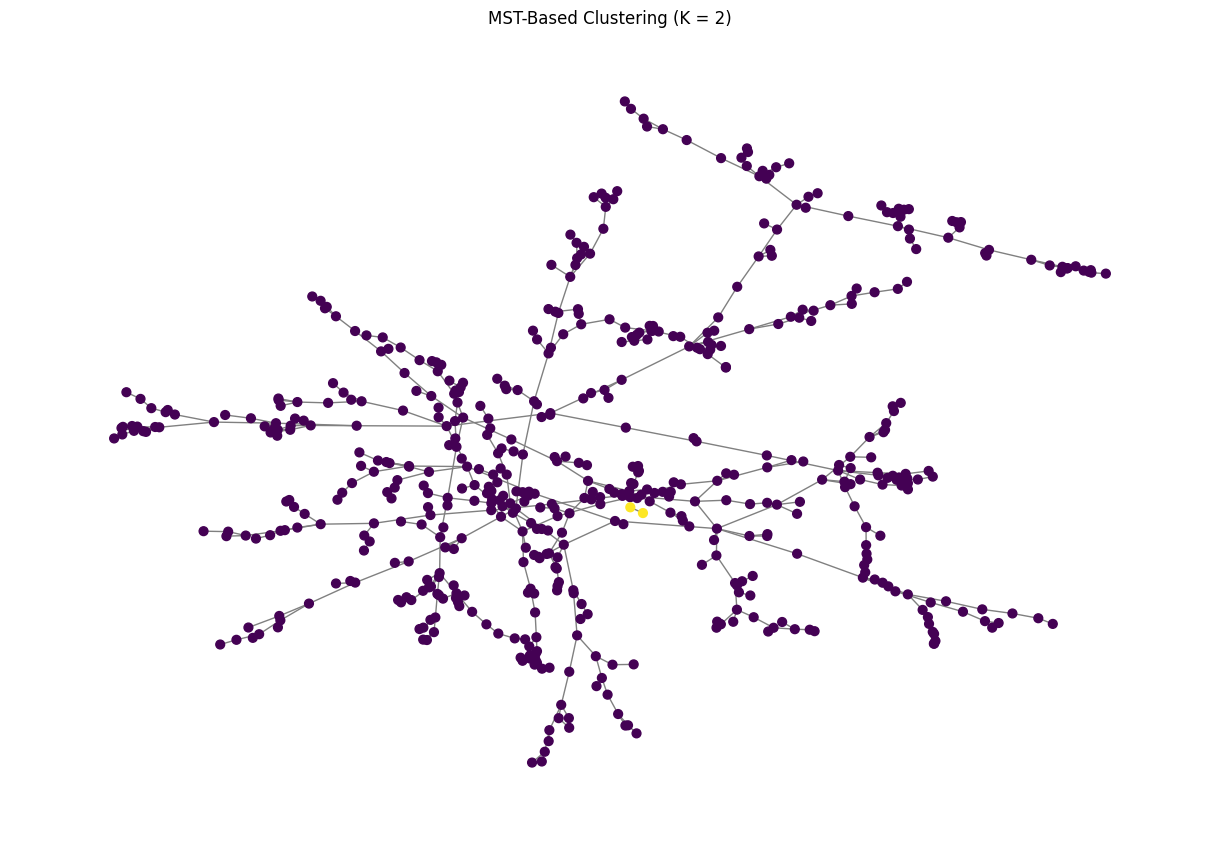

In [13]:
# Visualize the 2 Clusters

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(cluster_graph, seed=42)

nx.draw(
    cluster_graph,
    pos,
    node_color=cluster_labels,
    cmap="viridis",
    with_labels=False,
    node_size=40,
    edge_color="gray"
)

plt.title("MST-Based Clustering (K = 2)")
plt.show()

# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [14]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Silhouette Score
sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", round(sil_score, 4))

# Ground truth labels
y_true = df["y"].astype(str).str.strip().str.upper()

# Convert M/B labels to numbers
y_true = y_true.map({
    "M": 1,
    "B": 0
})

# Adjusted Rand Index
ari_score = adjusted_rand_score(
    y_true,
    cluster_labels
)

# Normalized Mutual Information
nmi_score = normalized_mutual_info_score(
    y_true,
    cluster_labels
)

print("Adjusted Rand Index (ARI):", round(ari_score, 4))

print(
    "Normalized Mutual Information (NMI):",
    round(nmi_score, 4)
)

Silhouette Score: 0.6607
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

In [15]:
# Task 8: Visualize MST and Graph-Based Clusters

import numpy as np
import matplotlib.pyplot as plt

# Select Mean Radius
radius_col = next(
    (
        col for col in X.columns
        if "radius" in col.lower()
        and "mean" in col.lower()
    ),
    X.columns[0]
)

# Select Mean Texture
texture_col = next(
    (
        col for col in X.columns
        if "texture" in col.lower()
        and "mean" in col.lower()
    ),
    X.columns[1]
)

# Get column positions
radius_index = list(X.columns).index(radius_col)
texture_index = list(X.columns).index(texture_col)

# Get standardized values
x_axis = X_scaled.iloc[:, radius_index]
y_axis = X_scaled.iloc[:, texture_index]

print("Feature 1:", radius_col)
print("Feature 2:", texture_col)

Feature 1: x.radius_mean
Feature 2: x.texture_mean


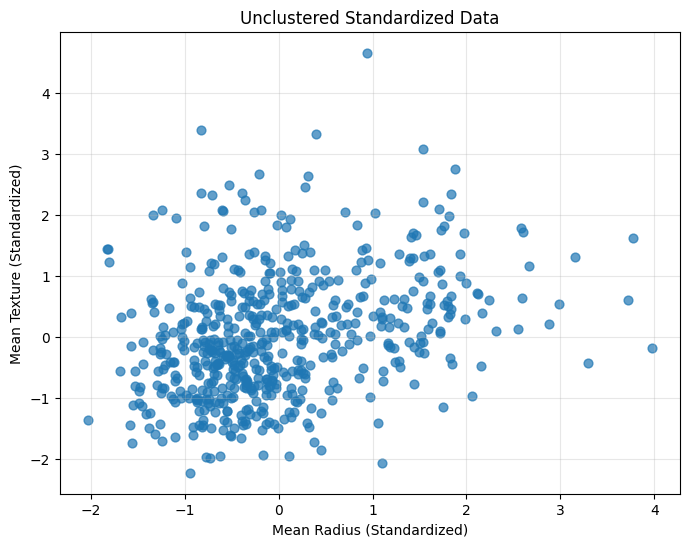

In [16]:
# Plot 1: Unclustered Standardized Data

plt.figure(figsize=(8, 6))

plt.scatter(
    x_axis,
    y_axis,
    s=40,
    alpha=0.7
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Unclustered Standardized Data")

plt.grid(True, alpha=0.3)

plt.show()

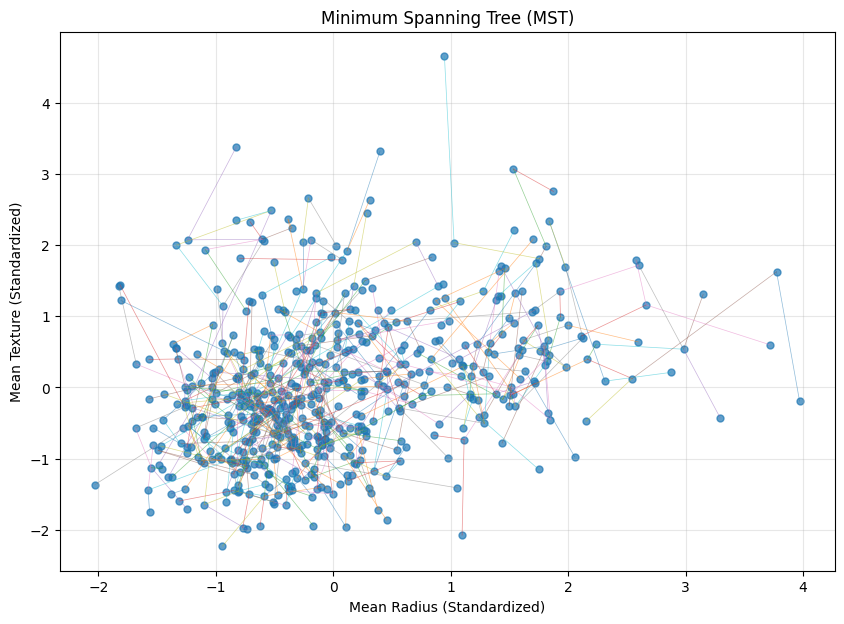

In [17]:
# Plot 2: MST Edge Connections

plt.figure(figsize=(10, 7))

# Plot all data points
plt.scatter(
    x_axis,
    y_axis,
    s=25,
    alpha=0.7
)

# Draw MST edges
for u, v, data in MST.edges(data=True):

    plt.plot(
        [x_axis.iloc[u], x_axis.iloc[v]],
        [y_axis.iloc[u], y_axis.iloc[v]],
        linewidth=0.5,
        alpha=0.5
    )

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Minimum Spanning Tree (MST)")

plt.grid(True, alpha=0.3)

plt.show()

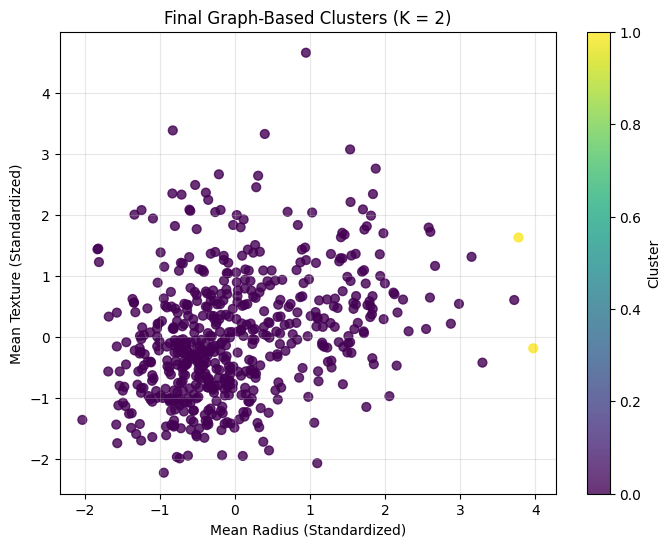

In [18]:
# Plot 3: Final Graph-Based Clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    x_axis,
    y_axis,
    c=cluster_labels,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")

plt.title("Final Graph-Based Clusters (K = 2)")

plt.colorbar(label="Cluster")

plt.grid(True, alpha=0.3)

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.